In [393]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [394]:
file = uproot.open("build/yz.root")

print(file.keys()) 
tree = file["yz"]
df = tree.arrays(library="pd")

['yz;1']


### STEP 1
Plottare tutte e quantità del file

In [395]:
custom_ranges = {
    'radius': None,
    'nbHits': None,
    'nbScoredHits': None,
    'y': None,
    'z': None,
    'Einc': (-0.02, 0.02)
}

cols_to_plot = ['radius', 'nbHits', 'nbScoredHits', 'y', 'z', 'Einc']

units = {
    'radius': ' [nm]',
    'nbHits': '',
    'nbScoredHits': '',
    'y': ' [keV/um]',
    'z': ' [Gy]',
    'Einc': ' [MeV]'
} # Controlla se sto facendo bene...!

count = len(df)
# Senza [1:], includi TUTTI gli indici trovati
counts = df['nbScoredHits'].value_counts().sort_index()

n_zeros = (df['nbScoredHits'] == 0).sum()
print(f"Number of events with nbEdep = 0: {n_zeros}")

for i, count in counts.items():
    print(f"Number of events with nbEdep = {int(i)}: {int(count)}")

# Somma totale di tutto quello che hai trovato
print(f"Total of number of Event = {counts.sum()}")

Number of events with nbEdep = 0: 0
Number of events with nbEdep = 1: 845
Number of events with nbEdep = 2: 436
Number of events with nbEdep = 3: 490
Number of events with nbEdep = 4: 457
Number of events with nbEdep = 5: 352
Number of events with nbEdep = 6: 313
Number of events with nbEdep = 7: 244
Number of events with nbEdep = 8: 220
Number of events with nbEdep = 9: 207
Number of events with nbEdep = 10: 190
Number of events with nbEdep = 11: 219
Number of events with nbEdep = 12: 194
Number of events with nbEdep = 13: 115
Number of events with nbEdep = 14: 96
Number of events with nbEdep = 15: 112
Number of events with nbEdep = 16: 107
Number of events with nbEdep = 17: 98
Number of events with nbEdep = 18: 57
Number of events with nbEdep = 19: 56
Number of events with nbEdep = 20: 42
Number of events with nbEdep = 21: 39
Number of events with nbEdep = 22: 33
Number of events with nbEdep = 23: 40
Number of events with nbEdep = 24: 43
Number of events with nbEdep = 25: 39
Number o

 Istogramma radius ha un range impostato a: None
 Istogramma nbHits ha un range impostato a: None
 Istogramma nbScoredHits ha un range impostato a: None
 Istogramma y ha un range impostato a: None
 Istogramma z ha un range impostato a: None
 Istogramma Einc ha un range impostato a: (-0.02, 0.02)


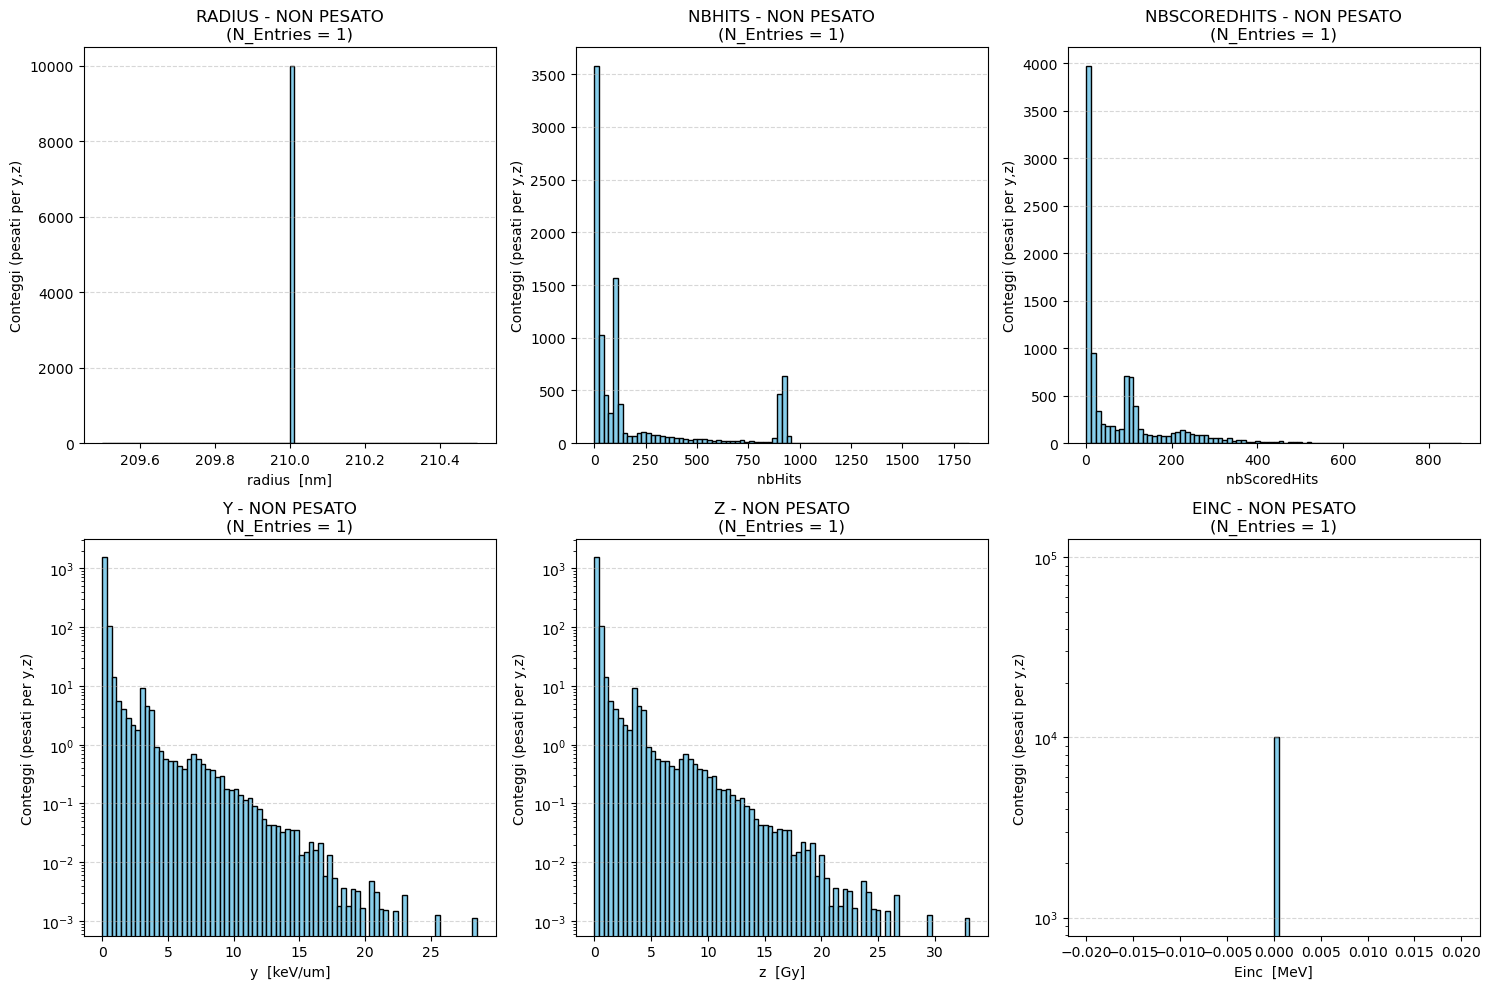

In [396]:
import matplotlib.pyplot as plt
import numpy as np

# 1. CALCOLO PESI (Una sola volta)
# Se nbScoredHits è > 0, il peso è 1/nbScoredHits, altrimenti è 0
df['weight'] = 1.0 / df['nbScoredHits']

# 2. DEFINIZIONE DELLE COLONNE E RANGE (Puoi personalizzare i range qui)
cols_to_plot = ['radius', 'nbHits', 'nbScoredHits', 'y', 'z', 'Einc']

# 3. PLOTTING
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    current_range = custom_ranges.get(col)
    print(f" Istogramma {col} ha un range impostato a: {current_range}")
    # Applichiamo il peso SOLO se la colonna è 'y' o 'z'
    current_weights = df['weight'] if col in ['y', 'z'] else None
    
    # Decidiamo la scala logaritmica (opzionale, basato sui tuoi dati)
    is_log = col in ['y', 'z', 'Einc']
    
    # Plot dell'istogramma
    axes[i].hist(df[col], bins=80, range=custom_ranges.get(col), 
                 color='skyblue', edgecolor='black', log=is_log, 
                 weights=current_weights)
    
    axes[i].set_title(f'{col.upper()} - NON PESATO\n(N_Entries = {count})')
    axes[i].set_xlabel(f'{col} {units.get(col, "")}')
    axes[i].set_ylabel('Conteggi (pesati per y,z)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

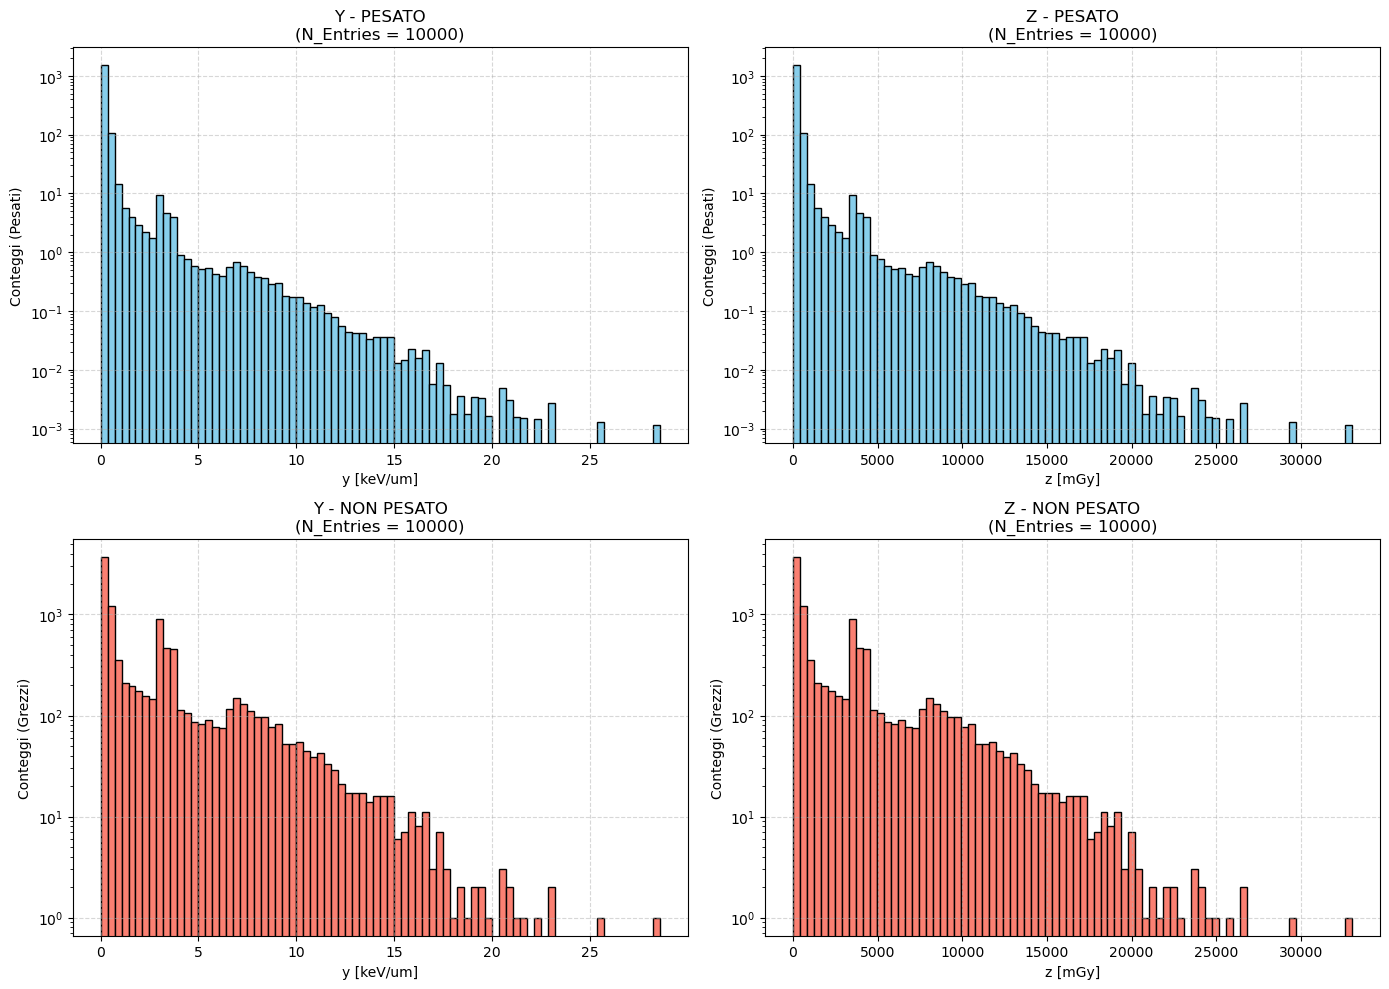

In [397]:
import matplotlib.pyplot as plt
import numpy as np

# Fattori di conversione
scales = {'y': 1.0, 'z': 1000.0}
units_label = {'y': 'keV/um', 'z': 'mGy'}

# Creiamo la figura
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# Definiamo le colonne
cols = ['y', 'z']

for i, col in enumerate(cols):
    data = df[col] * scales[col]
    
    # Calcolo conteggi
    # Per il non pesato: numero puro di eventi
    count = len(df)
    
    # 1. GRAFICO PESATO (Corretto)
    axes[0, i].hist(data, bins=80, range=None, weights=df['weight'], 
                    color='skyblue', edgecolor='black', log=True)
    axes[0, i].set_title(f'{col.upper()} - PESATO\n(N_Entries = {count:.0f})')
    axes[0, i].set_ylabel('Conteggi (Pesati)')
    axes[0, i].set_xlabel(f'{col} [{units_label[col]}]')
    axes[0, i].grid(linestyle='--', alpha=0.5)

    # 2. GRAFICO NON PESATO (Grezzo)
    axes[1, i].hist(data, bins=80, range=None, weights=None, 
                    color='salmon', edgecolor='black', log=True)
    axes[1, i].set_title(f'{col.upper()} - NON PESATO\n(N_Entries = {count})')
    axes[1, i].set_ylabel('Conteggi (Grezzi)')
    axes[1, i].set_xlabel(f'{col} [{units_label[col]}]')
    axes[1, i].grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Step 2
Entriamo nello specifico della lineal energy, y, e della specific energy, z.

Calcoliamo $y_F$ e $z_F$.

In [398]:
# Filtriamo i dati per evitare divisioni per zero o valori non fisici
y_data = df[df['y'] > 0]['y']

# 1. Media in frequenza (y_F)
y_f = y_data.mean()

# 2. Media in dose (y_D)
# Formula: somma(y^2) / somma(y)
y_d = (y_data**2).sum() / y_data.sum()

# 3. Varianza e Deviazione Standard (della distribuzione in frequenza)
y_var = y_data.var()
y_std = y_data.std()

print(f"Media in frequenza: {y_f:.4f} keV/µm")
print(f"Media in dose: {y_d:.4f} keV/µm")
print(f"Deviazione standard: {y_std:.4f} keV/µm")
print(f"Numero di eventi considerati: {len(y_data)}")

Media in frequenza: 2.5806 keV/µm
Media in dose: 6.9770 keV/µm
Deviazione standard: 3.3685 keV/µm
Numero di eventi considerati: 10000


### Step 3
Intera pipeline dalle quantità microdosimetriche a MKM e LQ model.

In [399]:
R_d=0.420
R_n=4
y0=150
alpha_0 = 0.147 #Per v79 [Gy^-1]
beta_cell = 0.02   #Per v79 [Gy^-2]

      Caso |   Dose Nucleo [Gy] |   Sopravvivenza
--------------------------------------------------
       100 |             0.3434 |      8.2908e-01
       200 |             0.6888 |      6.8335e-01
       300 |             1.0382 |      5.5932e-01
       400 |             1.3797 |      4.5767e-01
       500 |             1.7233 |      3.7232e-01
       600 |             2.0750 |      2.9992e-01
       700 |             2.4163 |      2.4207e-01
       800 |             2.7699 |      1.9288e-01
       900 |             3.1126 |      1.5411e-01
      1000 |             3.4499 |      1.2291e-01
      1100 |             3.7978 |      9.6943e-02
      1200 |             4.1510 |      7.5814e-02
      1300 |             4.4994 |      5.9216e-02
      1400 |             4.8460 |      4.6057e-02
      1500 |             5.1793 |      3.5975e-02
      1600 |             5.5360 |      2.7524e-02
      1700 |             5.8772 |      2.1210e-02
      1800 |             6.2294 |      1.6121e-02

      1900 |             6.5656 |      1.2353e-02
      2000 |             6.9125 |      9.3427e-03


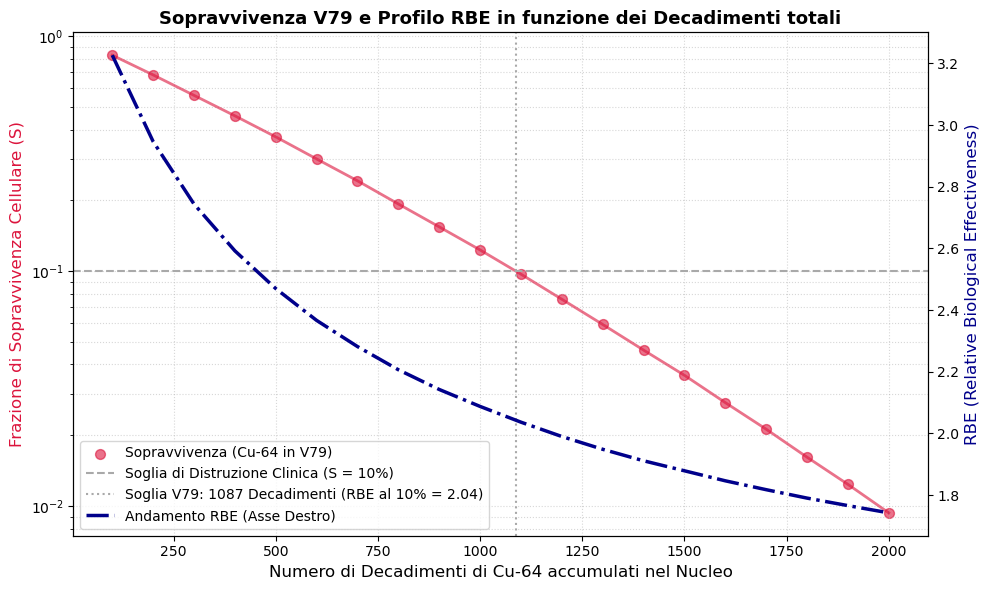

In [400]:
# ==============================================================================
# CALCOLO MICRODOSIMETRICO E MODELLO MKM (VERSIONE OTTIMIZZATA)
# ==============================================================================

# 1. PARAMETRI E CALCOLO FATTORE GEOMETRICO
k_conv = 0.1602 / (np.pi * (R_d**2))
rapporto_volumi = (R_d / R_n)**3 
rng = np.random.default_rng()

# 2. ELABORAZIONE DATI (Peso in dose)
y_data = df[df['y'] > 0]['y'].to_numpy()
z_data = df[df['z'] > 0]['z'].to_numpy()
sum_y = y_data.sum()

# Calcolo y* pesato correttamente per la distribuzione in dose d(y)
# Formalismo: y* = integral( y0^2 * (1 - exp(-y^2/y0^2)) * d(y) dy )
saturation_function = (y0**2) * (1 - np.exp(-(y_data**2) / (y0**2)))
y_star = np.sum(saturation_function * (y_data / sum_y))

# Alpha cellulare MKM
alpha_cell = alpha_0 + (beta_cell * k_conv * y_star)

# 3. PIPELINE MULTI-CASO (Range esteso)
casi_eventi = np.linspace(100, 2000, 20) 

risultati_sopravvivenza = []
dosi_medie_nucleo = []

print(f"{'Caso':>10} | {'Dose Nucleo [Gy]':>18} | {'Sopravvivenza':>15}")
print("-" * 50)

for N in casi_eventi:
    tentativi_bootstrap = 500
    sopravvivenze_tentativi = []
    dosi_tentativi = []
    
    for _ in range(tentativi_bootstrap):
        # Conversione esplicita in int per evitare l'errore TypeError
        sample_z = rng.choice(z_data, size=int(N), replace=True)
        
        # Dose calcolata sulla distribuzione in dose
        dose_totale_nucleo = sample_z.sum() * rapporto_volumi
        
        # Modello LQ
        S = np.exp(-alpha_cell * dose_totale_nucleo - beta_cell * (dose_totale_nucleo**2))
        
        sopravvivenze_tentativi.append(S)
        dosi_tentativi.append(dose_totale_nucleo)
        
    S_media = np.mean(sopravvivenze_tentativi)
    D_media = np.mean(dosi_tentativi)
    
    risultati_sopravvivenza.append(S_media)
    dosi_medie_nucleo.append(D_media)
    print(f"{int(N):10d} | {D_media:18.4f} | {S_media:15.4e}")

# 4. ANALISI SOGLIA
soglia_biologica = 0.10
log_S_rev = np.log(np.array(risultati_sopravvivenza)[::-1])
casi_rev = casi_eventi[::-1]
decadimenti_soglia = np.interp(np.log(soglia_biologica), log_S_rev, casi_rev)

dose_soglia_sim = decadimenti_soglia * (z_data.mean() * rapporto_volumi)
dose_soglia_ref = (-alpha_0 + np.sqrt(alpha_0**2 - 4 * beta_cell * np.log(soglia_biologica))) / (2 * beta_cell)
rbe_al_10 = dose_soglia_ref / dose_soglia_sim

# ==============================================================================
# 5. GRAFICO FINALE A DOPPIO ASSE: SOPRAVVIVENZA CELLULARE + CURVA RBE
# ==============================================================================
fig, ax1 = plt.subplots(figsize=(10, 6))

# ASSE SINISTRO: Frazione di Sopravvivenza (S)
color_s = 'crimson'
ax1.scatter(casi_eventi, risultati_sopravvivenza, color=color_s, s=50, alpha=0.6, label='Sopravvivenza (Cu-64 in V79)')
ax1.plot(casi_eventi, risultati_sopravvivenza, color=color_s, linestyle='-', alpha=0.6, linewidth=2)
ax1.set_yscale('log')
ax1.set_xlabel("Numero di Decadimenti di Cu-64 accumulati nel Nucleo", fontsize=12)
ax1.set_ylabel("Frazione di Sopravvivenza Cellulare (S)", color=color_s, fontsize=12)
ax1.grid(True, which="both", linestyle=":", alpha=0.5)

# ASSE DESTRO: RBE variabile
ax2 = ax1.twinx()
color_rbe = 'darkblue'
dosi_ref_casi = (-alpha_0 + np.sqrt(alpha_0**2 - 4 * beta_cell * np.log(risultati_sopravvivenza))) / (2 * beta_cell)
rbe_casi = dosi_ref_casi / np.array(dosi_medie_nucleo)
ax2.plot(casi_eventi, rbe_casi, color=color_rbe, linestyle='-.', linewidth=2.5, label='Andamento RBE (Asse Destro)')
ax2.set_ylabel("RBE (Relative Biological Effectiveness)", color=color_rbe, fontsize=12)

# --- SOGLIE BIOLOGICHE E VERTICALI ---
line_soglia = ax1.axhline(y=soglia_biologica, color='darkgray', linestyle='--', linewidth=1.5, 
                         label=f'Soglia di Distruzione Clinica (S = {int(soglia_biologica*100)}%)')

line_vert = ax1.axvline(x=decadimenti_soglia, color='darkgray', linestyle=':', linewidth=1.5,
                        label=f'Soglia V79: {int(np.ceil(decadimenti_soglia))} Decadimenti (RBE al 10% = {rbe_al_10:.2f})')

# UNIONE DELLE LEGENDE (Fondamentale per avere tutto in un unico box)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='lower left')

plt.title("Sopravvivenza V79 e Profilo RBE in funzione dei Decadimenti totali", fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()


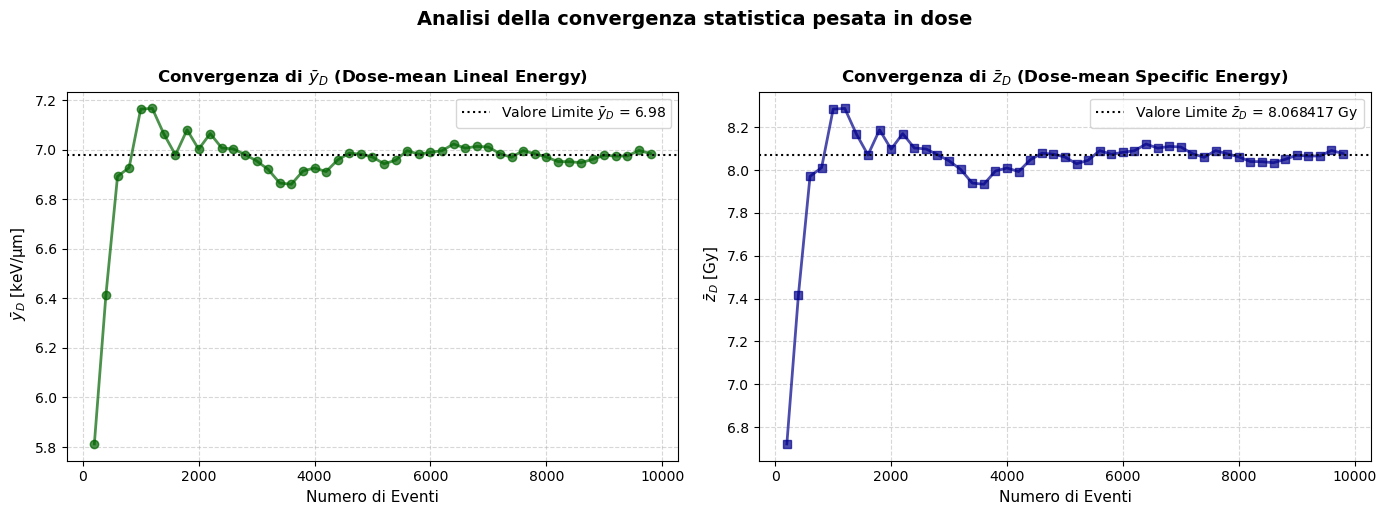

In [401]:
# ==============================================================================
# STUDIO DELLA CONVERGENZA STATISTICA DI y_D E z_D (PESATI IN DOSE)
# ==============================================================================
# Partiamo da un numero minimo di eventi (es. 'step') per evitare divisioni per zero all'inizio
step = 200
step_statistica = np.arange(step, len(y_data), step) 

y_d_cumulativi = []
z_d_cumulativi = []

# Calcoliamo i valori "di riferimento" (limiti) sull'intero dataset per le linee orizzontali
ref_y_d = np.sum(y_data**2) / np.sum(y_data)
ref_z_d = np.sum(z_data**2) / np.sum(z_data)

for n_eventi in step_statistica:
    # Estraiamo i sottogruppi
    y_sub = y_data[:n_eventi]
    z_sub = z_data[:n_eventi]
    
    # Calcolo della media pesata in dose (Dose-mean)
    # Formula: sum(x^2) / sum(x)
    y_d_cumulativi.append(np.sum(y_sub**2) / np.sum(y_sub))
    z_d_cumulativi.append(np.sum(z_sub**2) / np.sum(z_sub))

# Convertiamo in array
y_d_cumulativi = np.array(y_d_cumulativi)
z_d_cumulativi = np.array(z_d_cumulativi)

# --- GENERAZIONE DEL GRAFICO DI CONVERGENZA PESATA ---
fig, (ax_y, ax_z) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot per y_D
ax_y.plot(step_statistica, y_d_cumulativi, marker='o', color='darkgreen', linewidth=2, linestyle='-', alpha=0.7)
ax_y.axhline(y=ref_y_d, color='black', linestyle=':', label=f'Valore Limite $\\bar{{y}}_D$ = {ref_y_d:.2f}')
ax_y.set_xlabel("Numero di Eventi", fontsize=11)
ax_y.set_ylabel(r" $\bar{y}_D$ [keV/µm]", fontsize=11)
ax_y.set_title(r"Convergenza di $\bar{y}_D$ (Dose-mean Lineal Energy)", fontsize=12, fontweight='bold')
ax_y.grid(True, linestyle='--', alpha=0.5)
ax_y.legend()

# 2. Plot per z_D
ax_z.plot(step_statistica, z_d_cumulativi, marker='s', color='darkblue', linewidth=2, linestyle='-', alpha=0.7)
ax_z.axhline(y=ref_z_d, color='black', linestyle=':', label=f'Valore Limite $\\bar{{z}}_D$ = {ref_z_d:.6f} Gy')
ax_z.set_xlabel("Numero di Eventi", fontsize=11)
ax_z.set_ylabel(r" $\bar{z}_D$ [Gy]", fontsize=11)
ax_z.set_title(r"Convergenza di $\bar{z}_D$ (Dose-mean Specific Energy)", fontsize=12, fontweight='bold')
ax_z.grid(True, linestyle='--', alpha=0.5)
ax_z.legend()

plt.suptitle("Analisi della convergenza statistica pesata in dose", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 3.1 Analisi di Convergenza e Validazione Statistica del Dataset Monte Carlo

Al fine di verificare la solidità statistica del dataset generato tramite il codice **GEANT4**, è stata condotta un'analisi di convergenza cumulativa sulle grandezze microdosimetriche fondamentali, campionando i vettori con un passo discreto di 100 eventi.

I profili della *lineal energy* media in frequenza ($\bar{y}_F$) e della corrispondente *specific energy* ($\bar{z}_F$) mostrano un marcato andamento oscillatorio stocastico nella regione inferiore a **4.000 eventi**. Tale comportamento a dente di sega riflette la natura discreta ed eterogenea dello spettro di emissione del $^{64}\text{Cu}$, in cui la presenza sporadica di cascate di elettroni Auger a cortissimo range determina repentine fluttuazioni sul valore medio parziale.

All'aumentare della statistica integrata, l'ampiezza di tali oscillazioni subisce uno smorzamento progressivo dovuto alla saturazione dello spazio delle fasi del campionamento. Nella finestra compresa tra **6.000 e 10.000 eventi**, le curve mostrano un chiaro plateau di convergenza stocastica, stabilizzandosi asintoticamente sui seguenti valori definitivi:

* **$\bar{y}_F$ =** $2.58 \text{ keV/}\mu\text{m}$
* **$\bar{z}_F$ =** $2.98 \text{ Gy}$

Tale andamento dimostra che il paniere di **10.000 eventi totali** garantisce l'annullamento dell'incertezza statistica sulle medie globali, validando l'accuratezza dei parametri dosimetrici inseriti nel successivo calcolo radiobiologico del modello LQ-MKM.


### 3.2 Il Ruolo di $\bar{y}_F$ e $\bar{z}_F$ nella Descrizione della Stocasticità Microscopica

Il calcolo radiobiologico basato sul modello LQ-MKM ha evidenziato che la soglia terapeutica media per sterilizzare la cellula V79 è pari a **402 decadimenti** di $^{64}\text{Cu}$ nel nucleo (pari a una dose medoa assorbita di circa **2.98 Gy**). Tuttavia, questo numero rappresenta un valore medio geometrico e di popolazione. A livello microscopico e cellulare, entra in gioco la **stocasticità della radiazione**.

#### L'Esperimento Mentale
Per comprendere il significato fisico di questa stocasticità, si immagini un esperimento mentale in cui due singole cellule isolate vengano esposte, ciascuna, all'interazione di esattamente 402 eventi di decadimento di $^{64}\text{Cu}$:

1. **Cellula A (Campionamento sfortunato):** I 402 decadimenti avvengono secondo canali energetici meno efficienti (es. emissioni $\beta^-$ ad alta energia o fotoni gamma che sfuggono al volume nucleare senza interagire). La dose realmente depositata nei sub-domini cellulari sarà inferiore alla media e il danno biologico risulterà prevalentemente sub-letale e riparabile.
2. **Cellula B (Campionamento fortunato):** I 402 decadimenti innescano una serie di cascate di **elettroni Auger** ad energia bassissima e cortissimo range. Questi elettroni rilasciano pacchetti di energia enormi e densamente ionizzanti proprio all'interno dei sub-domini nanometrici da $210 \text{ nm}$. Il danno al DNA sarà massivo, letale e irreparabile.

Questo esempio dimostra che, a causa della natura probabilistica dei processi quantistici e delle interazioni nucleari, **iniettare o accumulare lo stesso numero di radionuclidi non garantisce l'assorbimento dell'esatta stessa dose di elettroni Auger** da parte di tutte le cellule. La risposta biologica reale oscilla vistosamente da voxel a voxel.

#### A che cosa servono, quindi, $\bar{y}_F$ e $\bar{z}_F$?
È precisamente in questo contesto che emerge l'importanza fondamentale delle grandezze medie spettrali estratte da **GEANT4**:

* **La Specific Energy Media ($\bar{z}_F$):** Rappresenta la dose media depositata dal singolo evento stocastico. Non è un semplice coefficiente di calcolo, ma è il parametro fisico necessario per quantificare la *funzione di distribuzione della dose* e mappare l'ampiezza delle fluttuazioni energetiche (la varianza del deposito) subite dalla cellula.
* **La Lineal Energy Media in Frequenza ($\bar{y}_F$):** Descrive la struttura microscopica intrinseca della traccia ionizzante. Dice al modello radiobiologico con quale frequenza e probabilità lo spettro del $^{64}\text{Cu}$ oscillerà verso la produzione di quegli eventi Auger densamente ionizzanti (alto LET locale) capaci di massimizzare il danno biologico rispetto alla radiazione di riferimento.

In conclusione, mentre il numero di decadimenti (402) definisce la prescrizione macroscopica della terapia, **$\bar{y}_F$ e $\bar{z}_F$ sono le chiavi matematiche che descrivono e governano le fluttuazioni microscopiche di quella stessa terapia**, permettendo al modello MKM di correggere la radiosensibilità ($\alpha_{\text{cell}}$) incorporando l'esatta impronta stocastica del radionuclide simulato.
